# Stock Price Prediction with PyTorch

## Amazon (AMZN) LSTM Model

This project develops a stock price prediction model using PyTorch and a Long Short-Term Memory (LSTM) neural network. Historical Amazon (AMZN) closing prices from 2015 to 2024 are used to train the model.

The model uses a sequence of the previous 20 trading days to predict the closing price of the following trading day. Model performance is evaluated by comparing predicted prices with actual prices on unseen test data.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler

In [2]:
print("PyTorch version:", torch.__version__)
print("Setup successful!")

PyTorch version: 2.11.0+cpu
Setup successful!


In [3]:
!pip install yfinance -q

In [5]:
import yfinance as yf

## 2. Download Historical Stock Data

In [6]:
data = yf.download("AMZN", start="2015-01-01", end="2025-01-01")

print(data.head())

/tmp/ipykernel_2568/1607462025.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AMZN", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price         Close     High      Low     Open    Volume
Ticker         AMZN     AMZN     AMZN     AMZN      AMZN
Date                                                    
2015-01-02  15.4260  15.7375  15.3480  15.6290  55664000
2015-01-05  15.1095  15.4190  15.0425  15.3505  55484000
2015-01-06  14.7645  15.1500  14.6190  15.1120  70380000
2015-01-07  14.9210  15.0640  14.7665  14.8750  52806000
2015-01-08  15.0230  15.1570  14.8055  15.0160  61768000


In [7]:
print("Number of rows:", len(data))
print("Columns:", data.columns)

Number of rows: 2516
Columns: MultiIndex([( 'Close', 'AMZN'),
            (  'High', 'AMZN'),
            (   'Low', 'AMZN'),
            (  'Open', 'AMZN'),
            ('Volume', 'AMZN')],
           names=['Price', 'Ticker'])


In [8]:
data.columns = data.columns.get_level_values(0)

print(data.head())

Price         Close     High      Low     Open    Volume
Date                                                    
2015-01-02  15.4260  15.7375  15.3480  15.6290  55664000
2015-01-05  15.1095  15.4190  15.0425  15.3505  55484000
2015-01-06  14.7645  15.1500  14.6190  15.1120  70380000
2015-01-07  14.9210  15.0640  14.7665  14.8750  52806000
2015-01-08  15.0230  15.1570  14.8055  15.0160  61768000


In [9]:
price = data[['Close']].copy()

print(price.head())

Price         Close
Date               
2015-01-02  15.4260
2015-01-05  15.1095
2015-01-06  14.7645
2015-01-07  14.9210
2015-01-08  15.0230


## 3. Data Exploration and Visualization

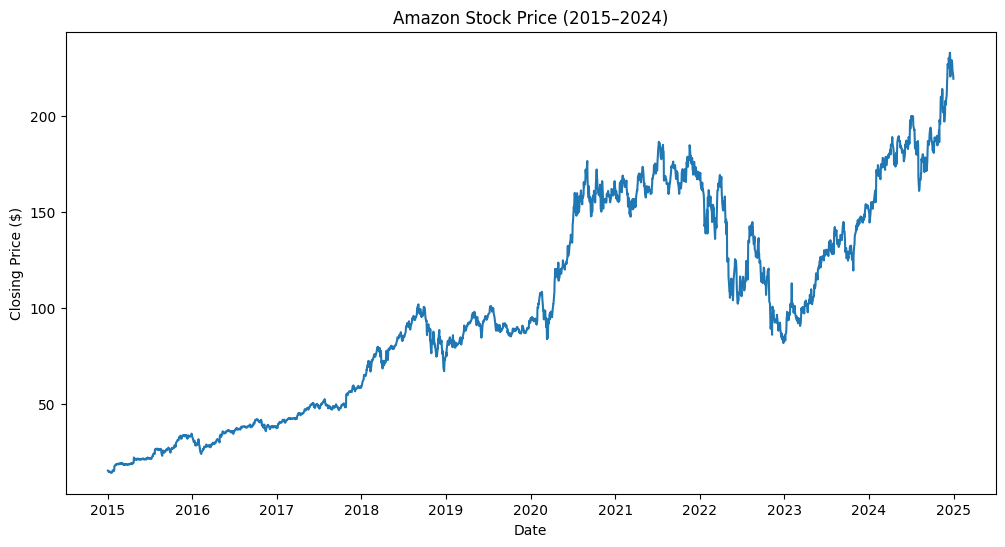

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(price.index, price['Close'])

plt.title('Amazon Stock Price (2015–2024)')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')

plt.show()

## 4. Data Preprocessing

In [11]:
scaler = MinMaxScaler(feature_range=(-1, 1))

price_scaled = scaler.fit_transform(price[['Close']])

print(price_scaled[:10])

[[-0.99013187]
 [-0.9930278 ]
 [-0.99618451]
 [-0.99475256]
 [-0.99381927]
 [-0.99543421]
 [-0.99795958]
 [-0.99643612]
 [-0.99710864]
 [-1.        ]]


## 5. Create Training Sequences

In [12]:
def create_sequences(data, lookback):
    X = []
    y = []

    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])

    return np.array(X), np.array(y)


lookback = 20

X, y = create_sequences(price_scaled, lookback)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2496, 20, 1)
y shape: (2496, 1)


## 6. Train-Test Split and PyTorch Tensors

In [13]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 1996
Testing examples: 500


In [14]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([1996, 20, 1])
y_train: torch.Size([1996, 1])
X_test: torch.Size([500, 20, 1])
y_test: torch.Size([500, 1])


## 7. LSTM Model

In [15]:
class LSTMModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        last_output = lstm_out[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [16]:
model = LSTMModel()

print(model)

LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [17]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

num_epochs = 100

## 8. Model Training

In [18]:
for epoch in range(num_epochs):

    model.train()

    predictions = model(X_train)

    loss = criterion(predictions, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.6f}")

Epoch 10/100, Loss: 0.038765
Epoch 20/100, Loss: 0.015928
Epoch 30/100, Loss: 0.007475
Epoch 40/100, Loss: 0.002629
Epoch 50/100, Loss: 0.001615
Epoch 60/100, Loss: 0.001369
Epoch 70/100, Loss: 0.001173
Epoch 80/100, Loss: 0.001114
Epoch 90/100, Loss: 0.001046
Epoch 100/100, Loss: 0.001011


## 9. Model Predictions

In [19]:
model.eval()

with torch.no_grad():
    test_predictions = model(X_test)

print(test_predictions.shape)
print(test_predictions[:5])

torch.Size([500, 1])
tensor([[-0.3501],
        [-0.3517],
        [-0.3494],
        [-0.3443],
        [-0.3353]])


In [20]:
predicted_prices = scaler.inverse_transform(test_predictions.numpy())
actual_prices = scaler.inverse_transform(y_test.numpy())

print("First 10 predictions vs actual prices:\n")

for i in range(10):
    print(
        f"Predicted: ${predicted_prices[i][0]:.2f} | "
        f"Actual: ${actual_prices[i][0]:.2f}"
    )

First 10 predictions vs actual prices:

Predicted: $85.37 | Actual: $83.12
Predicted: $85.20 | Actual: $86.08
Predicted: $85.45 | Actual: $87.36
Predicted: $86.01 | Actual: $89.87
Predicted: $87.00 | Actual: $95.09
Predicted: $88.87 | Actual: $95.27
Predicted: $90.74 | Actual: $98.12
Predicted: $92.80 | Actual: $96.05
Predicted: $94.22 | Actual: $95.46
Predicted: $95.09 | Actual: $93.68


## 10. Model Evaluation

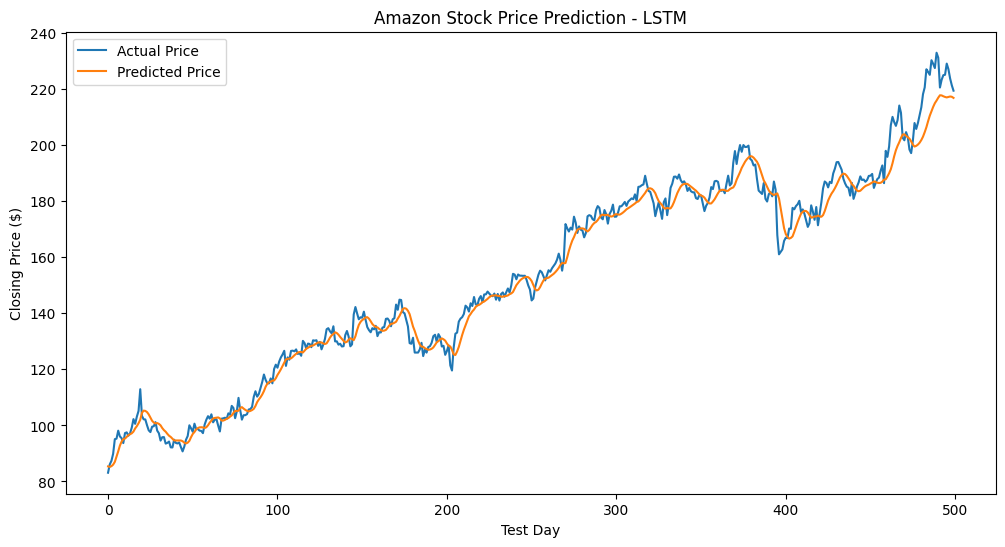

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')

plt.title('Amazon Stock Price Prediction - LSTM')
plt.xlabel('Test Day')
plt.ylabel('Closing Price ($)')
plt.legend()

plt.show()

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(actual_prices, predicted_prices)
mae = mean_absolute_error(actual_prices, predicted_prices)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

Mean Squared Error (MSE): 25.53
Mean Absolute Error (MAE): $3.70


In [24]:
rmse = np.sqrt(mse)

print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Root Mean Squared Error (RMSE): $5.05


## 11. GRU Model

In [25]:
class GRUModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(GRUModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        gru_out, _ = self.gru(x)

        last_output = gru_out[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [26]:
gru_model = GRUModel()

print(gru_model)

GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [27]:
gru_criterion = nn.MSELoss()

gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.01
)

gru_epochs = 100

In [28]:
for epoch in range(gru_epochs):

    gru_model.train()

    gru_predictions = gru_model(X_train)

    gru_loss = gru_criterion(gru_predictions, y_train)

    gru_optimizer.zero_grad()

    gru_loss.backward()

    gru_optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}/{gru_epochs}, "
            f"Loss: {gru_loss.item():.6f}"
        )

Epoch 10/100, Loss: 0.028208
Epoch 20/100, Loss: 0.002087
Epoch 30/100, Loss: 0.001017
Epoch 40/100, Loss: 0.000566
Epoch 50/100, Loss: 0.000603
Epoch 60/100, Loss: 0.000530
Epoch 70/100, Loss: 0.000513
Epoch 80/100, Loss: 0.000491
Epoch 90/100, Loss: 0.000470
Epoch 100/100, Loss: 0.000459


In [29]:
gru_model.eval()

with torch.no_grad():
    gru_test_predictions = gru_model(X_test)

gru_predicted_prices = scaler.inverse_transform(
    gru_test_predictions.numpy()
)

print(gru_predicted_prices[:5])

[[85.21415]
 [83.59032]
 [85.1006 ]
 [86.83777]
 [89.20931]]


In [30]:
gru_mse = mean_squared_error(
    actual_prices,
    gru_predicted_prices
)

gru_rmse = np.sqrt(gru_mse)

print(f"GRU Mean Squared Error (MSE): {gru_mse:.2f}")
print(f"GRU Root Mean Squared Error (RMSE): ${gru_rmse:.2f}")

GRU Mean Squared Error (MSE): 20.66
GRU Root Mean Squared Error (RMSE): $4.54


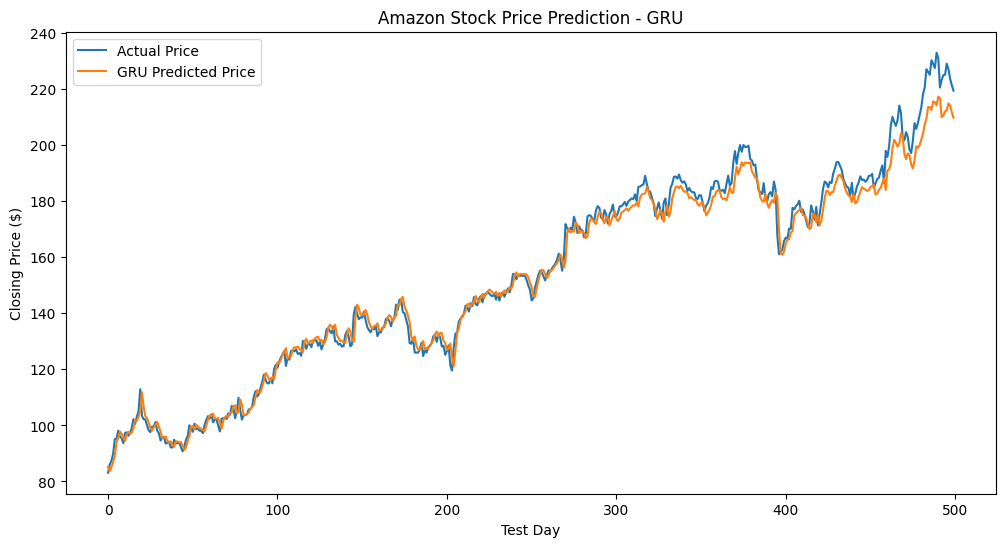

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(actual_prices, label='Actual Price')
plt.plot(gru_predicted_prices, label='GRU Predicted Price')

plt.title('Amazon Stock Price Prediction - GRU')
plt.xlabel('Test Day')
plt.ylabel('Closing Price ($)')
plt.legend()

plt.show()

In [32]:
print("MODEL COMPARISON")
print("--------------------------")
print(f"LSTM MSE:  {mse:.2f}")
print(f"LSTM RMSE: ${rmse:.2f}")
print()
print(f"GRU MSE:   {gru_mse:.2f}")
print(f"GRU RMSE:  ${gru_rmse:.2f}")

MODEL COMPARISON
--------------------------
LSTM MSE:  25.53
LSTM RMSE: $5.05

GRU MSE:   20.66
GRU RMSE:  $4.54


## Conclusion

This project compared Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) neural networks for predicting Amazon's daily closing stock price using PyTorch. Both models used the previous 20 trading days of closing prices to predict the following trading day's closing price and were trained for 100 epochs.

On the test dataset, the LSTM achieved an MSE of 25.53 and an RMSE of $5.05, while the GRU achieved an MSE of 20.66 and an RMSE of $4.54. Therefore, the GRU produced slightly better predictions based on both evaluation metrics. Both models generally followed the actual stock-price trend, although their predictions were smoother during sudden price movements.

Overall, the project demonstrates how recurrent neural networks such as LSTM and GRU can be applied to financial time-series prediction and how different architectures can be compared using quantitative performance metrics.